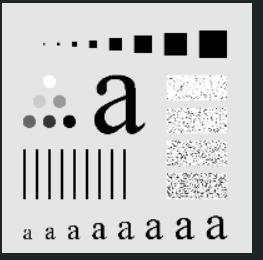

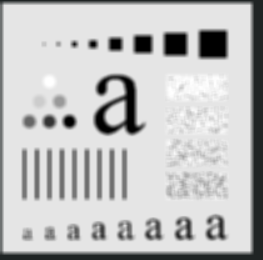

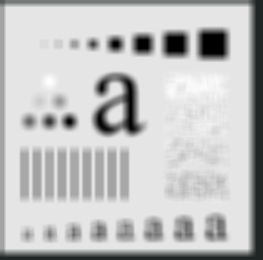

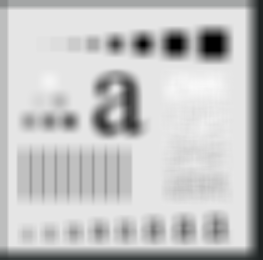

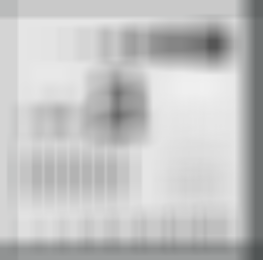

In [ ]:
import cv2
from google.colab.patches import cv2_imshow # Import the Colab-compatible imshow

def apply_averaging_filters(image_path):
    # Đọc ảnh đầu vào
    img = cv2.imread(image_path)

    if img is None:
        print("Không thể mở hoặc tìm thấy ảnh!")
        return

    # Danh sách các kích thước mặt nạ (kernel sizes)
    kernel_sizes = [5, 9, 15, 35]

    # Áp dụng bộ lọc trung bình cho từng kích thước
    filtered_images = {}
    for k in kernel_sizes:
        # cv2.blur áp dụng bộ lọc trung bình hình vuông kích thước (k, k)
        filtered_images[k] = cv2.blur(img, (k, k))

    # Hiển thị ảnh gốc và các ảnh sau khi lọc
    cv2_imshow(img) # Use cv2_imshow
    for k in kernel_sizes:
        cv2_imshow(filtered_images[k]) # Use cv2_imshow

    # cv2.waitKey(0) and cv2.destroyAllWindows() are not needed with cv2_imshow
    # as it displays images directly in the notebook output.

# Chạy thử nghiệm với tệp ảnh của bạn
apply_averaging_filters('/content/domat1.png')

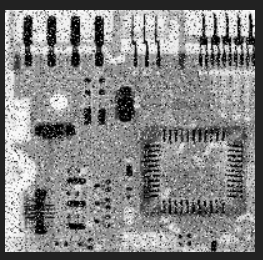

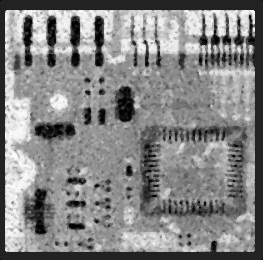

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # Import the Colab-compatible imshow

def MedianFilter(img, size):
    a = size // 2
    img_pad = np.pad(img, a, mode="constant", constant_values=0)

    H, W = img.shape
    img_out = np.zeros((H, W), dtype=np.uint8)

    for x in range(H):
        for y in range(W):
            w = np.zeros((size, size), dtype=np.uint8)
            for s in range(-a, a + 1):
                for t in range(-a, a + 1):
                    w[a + s, a + t] = img_pad[x + a + s, y + a + t]
            w_1D = np.reshape(w, (size * size,))
            w_sort = np.sort(w_1D)
            median = w_sort[(size * size) // 2]
            img_out[x, y] = median

    return img_out

# ----------------- CHƯƠNG TRÌNH CHÍNH -----------------
if __name__ == "__main__":
    # Đọc ảnh ở dạng ảnh xám (Grayscale)
    image_path = '/content/muoitieu.png'  # Thay tên file ảnh của em vào đây
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Không tìm thấy file ảnh! Vui lòng kiểm tra lại đường dẫn.")
    else:
        # Gọi hàm lọc trung vị với kích thước cửa sổ size = 3
        kernel_size = 3
        img_filtered = MedianFilter(img, kernel_size)

        # Hiển thị kết quả
        cv2_imshow(img) # Use cv2_imshow
        cv2_imshow(img_filtered) # Use cv2_imshow

        # cv2.waitKey(0) and cv2.destroyAllWindows() are not needed with cv2_imshow
        # as it displays images directly in the notebook output.


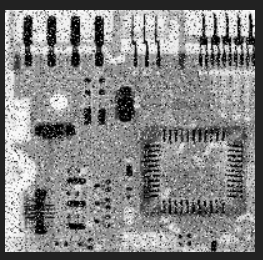

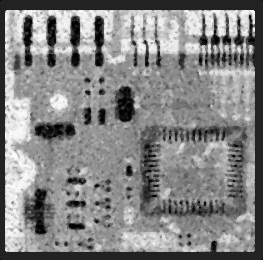

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # Import the Colab-compatible imshow

img_path = r'/content/muoitieu.png'

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

k = 3
a = k // 2

# Zero padding
img_pad = np.pad(img, a, mode='constant', constant_values=0)

H, W = img.shape

img_out = np.zeros((H, W), dtype=np.uint8)

for y in range(H):

    for x in range(W):

        value = []

        for s in range(-a, a + 1):

            for t in range(-a, a + 1):

                value.append(
                    int(img_pad[y + s + a, x + t + a])
                )

        # Sap xep
        value.sort()

        # Lay median
        img_out[y, x] = value[len(value) // 2]

cv2_imshow(img) # Use cv2_imshow
cv2_imshow(img_out) # Use cv2_imshow

# cv2.waitKey(0) and cv2.destroyAllWindows() are not needed with cv2_imshow
# as it displays images directly in the notebook output.